In [2]:
%pip install -r requirements.txt

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import json
import google.generativeai as genai
from dotenv import load_dotenv
import networkx as nx
import matplotlib.pyplot as plt
from pyvis.network import Network

In [4]:
%matplotlib inline

In [3]:
def convert_to_json(text):
    try:
        graph_json = json.loads(text)
    except json.JSONDecodeError:
        print("not valid JSON")
    
    with open("knowledge-graph.json", "w", encoding="utf-8") as f:
        json.dump(graph_json, f, indent=2)
    
    print("graph successfully saved to knowledge-graph.json")
    return graph_json

In [ ]:
# DO NOT RUN UNLESS CALLING API

load_dotenv()
api_key = os.getenv("GEMINI_API_KEY")
if not api_key:
    exit

genai.configure(api_key=api_key)
model = genai.GenerativeModel("gemini-2.5-pro")

with open("prompt.txt", "r", encoding="utf-8") as f:
    prompt = f.read()

print("Calling API:\n")
response = model.generate_content(prompt)
text = response.text
graph_json = convert_to_json(text)

In [5]:
file_path = 'knowledge-graph.json'

try:
    with open(file_path, 'r') as file:
        graph_json = json.load(file)
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found.")
except json.JSONDecodeError:
    print(f"Error: Failed to decode JSON from the file '{file_path}'. Check for malformed JSON.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

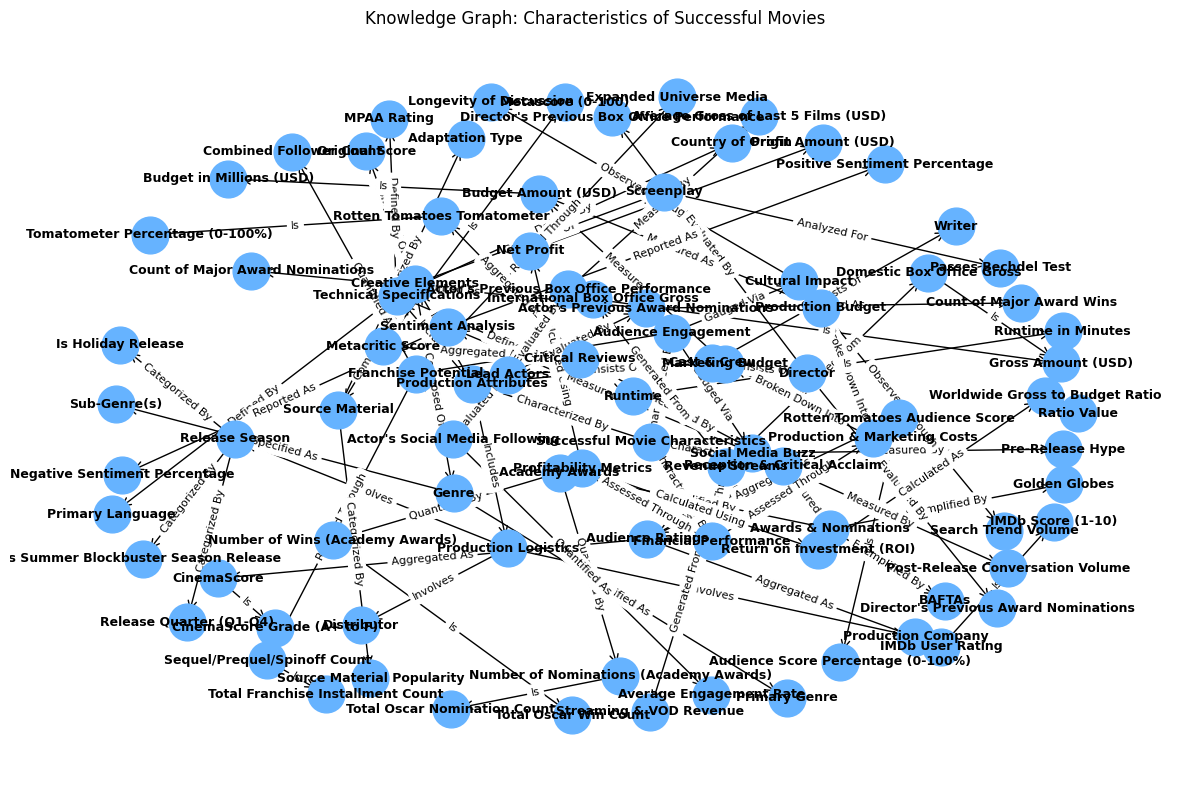

In [6]:
# build graph -> NetworkX library
G = nx.DiGraph()

for node, edges in graph_json.items():
    for edge in edges:
        neighbor = edge.get("neighbor")
        relation = edge.get("edge", "")
        if neighbor:
            G.add_node(node)
            G.add_node(neighbor)
            G.add_edge(node, neighbor, label=relation)

# visualize graph
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, k=0.5, iterations=50)
edge_labels = nx.get_edge_attributes(G, "label")

nx.draw_networkx_nodes(G, pos, node_size=700, node_color="#66b3ff")
nx.draw_networkx_edges(G, pos, arrows=True, arrowstyle="->", arrowsize=15)
nx.draw_networkx_labels(G, pos, font_size=9, font_weight="bold")
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

plt.title("Knowledge Graph: Characteristics of Successful Movies")
plt.axis("off")
plt.tight_layout()
plt.show()


In [8]:
net = Network(height="750px", width="100%", directed=True, bgcolor="#ffffff", font_color="#000000")
net.from_nx(G)

net.repulsion(
    node_distance=150,
    central_gravity=0.33,
    spring_length=200,
    spring_strength=0.05,
    damping=0.95
)

for src, dst, data in G.edges(data=True):
    label = data.get("label", "")
    if label:
        net.edges[-1]["title"] = label

net.show("knowledge_graph.html", notebook=False)


knowledge_graph.html
